**Lab 4: Control Flow for Data Cleaning**

**Problem Statement:
An organization is analyzing demographic and employment data for workforce analytics.
However, the dataset contains incomplete and potentially invalid observations. Before
performing statistical or predictive analysis, missing and inconsistent values must be
systematically identified and treated.
Use the UCI Adult dataset for this experiment. After loading the dataset, deliberately
introduce a small number of NA, blank strings (""), NaN, and impossible numeric values
such as age = 999 so that students can examine different missing-data scenarios.
Important R concept: NULL normally represents the absence of an R object rather than
a value inside a data-frame cell. Therefore, blank strings should not technically be
described as NULL. This lab should teach students the distinction between NA, NULL,
NaN, and ""..**


**Name**: Yashraj Patil

**Roll no**: 23102A0071

**Department and Division**: CMPN-A

**Lab mentor**: Prof. Prakash Parmar

In [12]:
# STEP 0: Install required packages (run once)
if (!require("naniar")) install.packages("naniar")
if (!require("skimr")) install.packages("skimr")
library(naniar)
library(skimr)

In [13]:
# STEP 1: Load the dataset
list.files("/content")   # confirm filename

df <- read.csv("/content/adult.csv", stringsAsFactors = FALSE)
names(df) <- gsub("[-. ]", "_", names(df))   # normalize column names

# This dataset marks missing values as "?" instead of blank -- convert to "" for consistency
df[df == "?"] <- ""

str(df)
head(df)

[1] "adult.csv"   "sample_data"

'data.frame':	32561 obs. of  15 variables:
 $ age           : int  90 82 66 54 41 34 38 74 68 41 ...
 $ workclass     : chr  "" "Private" "" "Private" ...
 $ fnlwgt        : int  77053 132870 186061 140359 264663 216864 150601 88638 422013 70037 ...
 $ education     : chr  "HS-grad" "HS-grad" "Some-college" "7th-8th" ...
 $ education_num : int  9 9 10 4 10 9 6 16 9 10 ...
 $ marital_status: chr  "Widowed" "Widowed" "Widowed" "Divorced" ...
 $ occupation    : chr  "" "Exec-managerial" "" "Machine-op-inspct" ...
 $ relationship  : chr  "Not-in-family" "Not-in-family" "Unmarried" "Unmarried" ...
 $ race          : chr  "White" "White" "Black" "White" ...
 $ sex           : chr  "Female" "Female" "Female" "Female" ...
 $ capital_gain  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ capital_loss  : int  4356 4356 4356 3900 3900 3770 3770 3683 3683 3004 ...
 $ hours_per_week: int  40 18 40 40 40 45 40 20 40 60 ...
 $ native_country: chr  "United-States" "United-States" "United-States" "United-States" ...


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,90,,77053,HS-grad,9,Widowed,,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,66,,186061,Some-college,10,Widowed,,Unmarried,Black,Female,0,4356,40,United-States,<=50K
4,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
5,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
6,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K


In [14]:
# STEP 2: Inject an impossible age value
# (dataset already has "?" for missing workclass/occupation/native_country,
#  so we only need to add the impossible-age scenario)
set.seed(2)
age_idx <- sample(1:nrow(df), 2)
df$age[age_idx] <- 999


In [15]:
# TASK 1: Identify different forms of missing/invalid data
cat("\n--- NA counts per column ---\n")
print(colSums(is.na(df)))

numeric_cols <- names(df)[sapply(df, is.numeric)]
cat("\n--- NaN counts (numeric columns) ---\n")
for (col in numeric_cols) {
  cat(col, ":", sum(is.nan(df[[col]])), "\n")
}

example_obj <- NULL
cat("\nIs example_obj NULL?", is.null(example_obj), "\n")
cat("Note: NULL represents the absence of an R object (e.g. an unassigned variable),\n")
cat("not a missing value inside a data-frame cell. A missing cell is NA. Blank strings\n")
cat("('') are also distinct from NULL/NA and must be checked separately using `== \"\"`.\n")

categorical_cols <- names(df)[sapply(df, is.character)]
blank_counts <- sapply(df[categorical_cols], function(x) sum(x == ""))
cat("\nBlank entries per categorical column:\n")
print(blank_counts)

impossible_age_count <- sum(df$age == 999)
cat("\nImpossible age values (999):", impossible_age_count, "\n")

cat("\n--- Missing value summary (before cleaning) ---\n")
summary_before <- miss_var_summary(df)
print(summary_before)


--- NA counts per column ---
           age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0              0              0 

--- NaN counts (numeric columns) ---
age : 0 
fnlwgt : 0 
education_num : 0 
capital_gain : 0 
capital_loss : 0 
hours_per_week : 0 

Is example_obj NULL? TRUE 
Note: NULL represents the absence of an R object (e.g. an unassigned variable),
not a missing value inside a data-frame cell. A missing cell is NA. Blank strings
('') are also distinct from NULL/NA and must be checked separately using `== ""`.

Blank entries per categorical column:
     workclass      education marital_status     occupation   relatio

In [16]:
# TASK 2: Missing-data treatment strategy
# Convert impossible numeric values to NA
df$age[df$age == 999] <- NA

# Replace blank categorical values with "Unknown"
for (col in categorical_cols) {
  df[[col]][df[[col]] == ""] <- "Unknown"
  df[[col]][is.na(df[[col]])] <- "Unknown"
}

# Impute missing numeric values using the median
for (col in numeric_cols) {
  med <- median(df[[col]], na.rm = TRUE)
  df[[col]][is.na(df[[col]])] <- med
}

complete_rows <- complete.cases(df)
cat("\nComplete rows:", sum(complete_rows), "/ Incomplete rows:", sum(!complete_rows), "\n")


Complete rows: 32561 / Incomplete rows: 0 


In [17]:
# TASK 3: Custom median-imputation function
impute_median <- function(x) {
  missing_mask <- is.na(x)
  med <- median(x[!missing_mask], na.rm = TRUE)
  x[missing_mask] <- med
  return(x)
}

test_vec <- c(10, NA, 20, NA, 30)
cat("\nimpute_median() demo on c(10, NA, 20, NA, 30):", impute_median(test_vec), "\n")


impute_median() demo on c(10, NA, 20, NA, 30): 10 20 20 20 30 



--- Missing value summary (after cleaning) ---
# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 age                 0        0
 2 workclass           0        0
 3 fnlwgt              0        0
 4 education           0        0
 5 education_num       0        0
 6 marital_status      0        0
 7 occupation          0        0
 8 relationship        0        0
 9 race                0        0
10 sex                 0        0
11 capital_gain        0        0
12 capital_loss        0        0
13 hours_per_week      0        0
14 native_country      0        0
15 income              0        0

--- Before/after comparison ---
         variable n_miss_before pct_miss_before n_miss_after pct_miss_after
1             age             0               0            0              0
2    capital_gain             0               0            0              0
3    capital_loss             0               0            0              0
4       education 

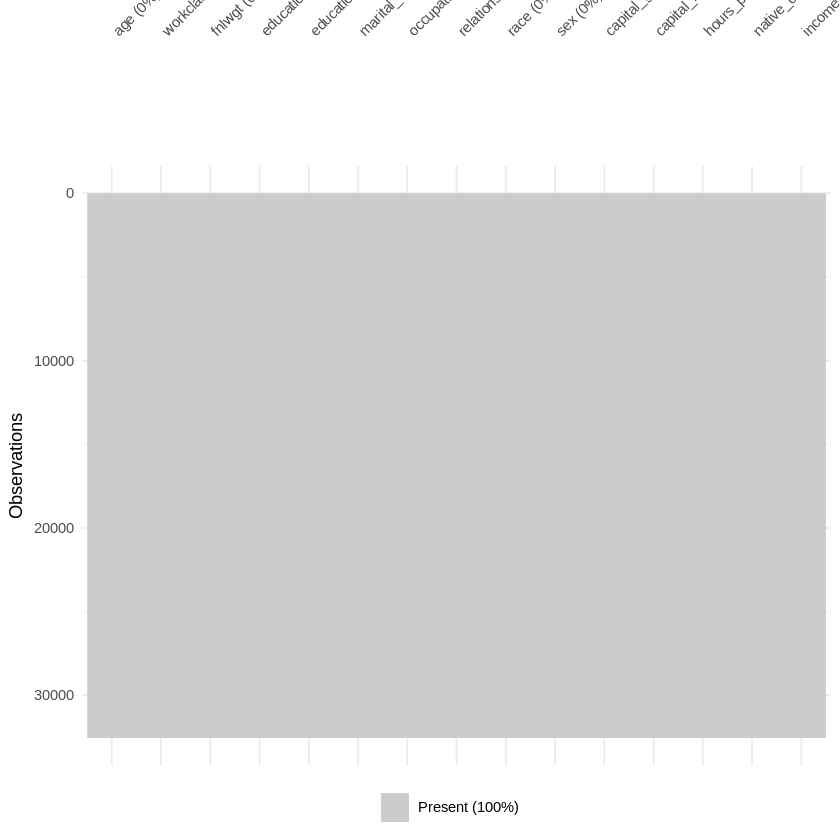

In [18]:
# TASK 4: Missingness before and after cleaning
cat("\n--- Missing value summary (after cleaning) ---\n")
summary_after <- miss_var_summary(df)
print(summary_after)

comparison <- merge(summary_before, summary_after, by = "variable",
                     suffixes = c("_before", "_after"))
cat("\n--- Before/after comparison ---\n")
print(comparison)

vis_miss(df)
ggplot2::ggsave("/content/missingness_plot.png", width = 8, height = 5)
cat("\nSaved missingness_plot.png to /content\n")

In [19]:
# TASK 5: Validate the cleaned dataset
cat("\n--- Final validation (skimr) ---\n")
print(skim(df))

cat("\nAny remaining age == 999?", any(df$age == 999), "\n")
cat("Any remaining NA in numeric columns?",
    any(sapply(df[numeric_cols], function(x) any(is.na(x)))), "\n")
cat("Any remaining blank strings?",
    any(sapply(df[categorical_cols], function(x) any(x == ""))), "\n")


--- Final validation (skimr) ---
── Data Summary ────────────────────────
                           Values
Name                       df    
Number of rows             32561 
Number of columns          15    
_______________________          
Column type frequency:           
  character                9     
  numeric                  6     
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────
  skim_variable  n_missing complete_rate min max empty n_unique whitespace
1 workclass              0             1   7  16     0        9          0
2 education              0             1   3  12     0       16          0
3 marital_status         0             1   7  21     0        7          0
4 occupation             0             1   5  17     0       15          0
5 relationship           0             1   4  14     0        6          0
6 race                   0             1   5  18     

In [20]:
# Save cleaned dataset
write.csv(df, "/content/cleaned_adult_data.csv", row.names = FALSE)
cat("\nSaved cleaned_adult_data.csv to /content\n")


Saved cleaned_adult_data.csv to /content


In [21]:
# Interpretation
cat("\nInterpretation: Impossible values (age = 999) and blank/'?' categorical entries\n")
cat("were converted to NA/'Unknown' and treated. Missing numeric values were imputed\n")
cat("using the median, which is robust to outliers. After cleaning, no unresolved NA,\n")
cat("NaN, or blank-string issues remain in the dataset.\n")


Interpretation: Impossible values (age = 999) and blank/'?' categorical entries
were converted to NA/'Unknown' and treated. Missing numeric values were imputed
using the median, which is robust to outliers. After cleaning, no unresolved NA,
NaN, or blank-string issues remain in the dataset.
